In [1]:
import dao
import torch
import numpy as np
import pylab as plt
from PhaseEstimator import Papyrus2ndStage, Papyrus2ndStageTiny
from FramePreprocess import FramePreprocess
import time
import numpy as np

In [2]:
def GetWFSFrame():
    frame = im_shm.get_data(check = True).astype(np.float32) - bg
    frame[:1,:] = 0
    frame = frame / frame.sum()

    return frame

def MakeReference():
    frame = GetWFSFrame()
    n_iter = 2000
    for i in range(n_iter):
        frame += GetWFSFrame()
    return frame / (n_iter + 1)

def PokeMode(mode, amplitude):
    coefs = GetModeCoefs(mode) * amplitude
    dmShm_test.set_data(coefs)

def GetModeCoefs(mode):
    coefs = np.expand_dims(M2C[:,mode],1)
    return coefs

In [3]:
device = 'cuda'
WFSParams = {"Nzernike": 50}
WFSParams['Nres'] = 90
WFSParams['Substract_Reference'] = False
WFSParams["Extract_pupils"] = True
WFSParams["Bin_factor"] = 1
binning = WFSParams["Bin_factor"]


centers = np.array([
                    [ 79, 66],
                    [170, 65],], dtype=np.int32) 


phaseEstimator = Papyrus2ndStage(WFSParams, 1, 1).to(device = device)
phaseEstimator.eval()

framePreprocess = FramePreprocess(WFSParams, 0, device, centers)


In [5]:
checkpoint_path = 'Test7.pth'
checkpoint = torch.load(checkpoint_path)
phaseEstimator.load_state_dict(checkpoint['PhaseEstimator_state_dict'])

/tmp/ipykernel_988278/193418934.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


<All keys matched successfully>

In [ ]:
bg = dao.shm(f"/tmp/cred2Bg.im.shm").get_data().astype(np.float32)
bg[:1,:] = 0
im_shm = dao.shm('/tmp/cred2.im.shm')
dmShm_test = dao.shm('/tmp/dm2ndStageCmd02.im.shm')
dmShm_cl = dao.shm('/tmp/dm2ndStageCmd01.im.shm')
dmShm_flat = dao.shm('/tmp/dm2ndStageCmd00.im.shm')

# ref = dao.shm('ozi_illum_pupil.im.shm').get_data().astype(np.float32)

nModes = 50
M2C = np.load('M2C_KL.npy')[:,:nModes].astype(np.float32)

2026-02-18_05:58:09:5155 [info] dao.c:daoShmShm2Img:707: shm name = cred2Bg.im.shm
2026-02-18_05:58:09:5178 [info] dao.c:daoShmShm2Img:711: local name: cred2Bg
2026-02-18_05:58:09:6095 [info] dao.c:daoShmShm2Img:707: shm name = cred2.im.shm
2026-02-18_05:58:09:6106 [info] dao.c:daoShmShm2Img:711: local name: cred2
2026-02-18_05:58:09:6365 [info] dao.c:daoShmShm2Img:707: shm name = dm2ndStageCmd02.im.shm
2026-02-18_05:58:09:6373 [info] dao.c:daoShmShm2Img:711: local name: dm2ndStageCmd02
2026-02-18_05:58:09:6602 [info] dao.c:daoShmShm2Img:707: shm name = dm2ndStageCmd01.im.shm
2026-02-18_05:58:09:6609 [info] dao.c:daoShmShm2Img:711: local name: dm2ndStageCmd01
2026-02-18_05:58:09:7057 [info] dao.c:daoShmShm2Img:707: shm name = dm2ndStageCmd00.im.shm
2026-02-18_05:58:09:7065 [info] dao.c:daoShmShm2Img:711: local name: dm2ndStageCmd00


In [15]:
PokeMode(0,0)

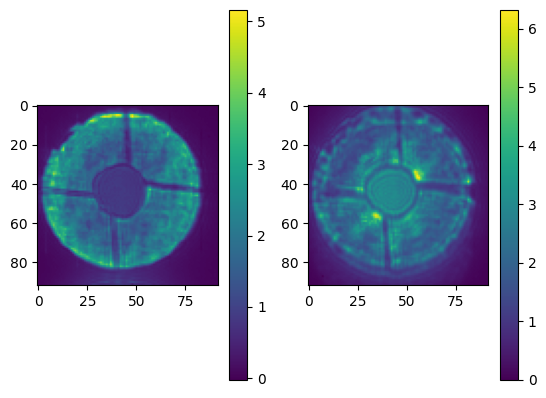

In [47]:
ref = MakeReference()
# ref = np.load('reference_intensity.npy')
framePreprocess.ProcessReference(ref)
plt.subplots(1,2)
plt.subplot(121)
plt.imshow(framePreprocess.reference[0])
plt.colorbar()
plt.subplot(122)
plt.imshow(framePreprocess.reference[1])
plt.colorbar()

[0.736183  1.0429214]


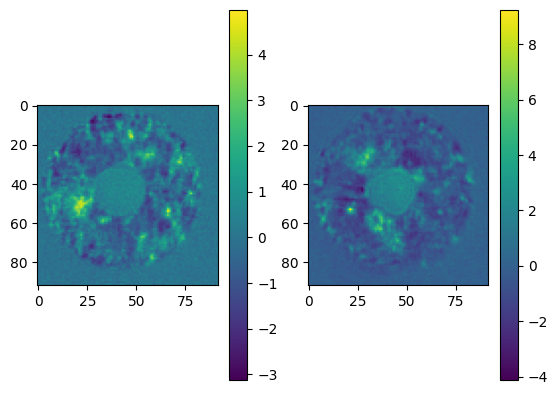

In [48]:
input_to_network = framePreprocess.ProcessFrame(GetWFSFrame())
plt.subplots(1,2)
plt.subplot(121)
plt.imshow(input_to_network[0])
plt.colorbar()
plt.subplot(122)
plt.imshow(input_to_network[1])
plt.colorbar()
print(input_to_network.std(axis = (-2,-1)))

In [55]:
dm_commands = np.zeros((97,1), dtype=np.float32)

dmShm_cl.set_data(dm_commands)

In [ ]:
dm_commands = np.zeros((97,1), dtype=np.float32)
dmShm_cl.set_data(dm_commands)
phaseEstimator.eval()


scale = np.expand_dims(np.linspace(0.2,1.,nModes, dtype = np.float32), 1)

for ii in range(10000):
    a = time.perf_counter() 
    with torch.no_grad():
        tfn = GetWFSFrame()
        
        input_to_network = framePreprocess.ProcessFrame(tfn)
        input_to_network = torch.from_numpy(input_to_network).to(device = device).unsqueeze(0)
        out = phaseEstimator(input_to_network).cpu().numpy().astype(np.float32).T * scale
        out = out[:nModes]

        wfs_measurement = M2C @ out
    

    dm_commands = dm_commands*0.9 - wfs_measurement * 0.2
    dmShm_cl.set_data(dm_commands)
    time.sleep(0.00)
    b = time.perf_counter()
    print(1/(b - a), end = '\r')
    

    # dm_commands[dm_commands > 0.4] = dm_flat[dm_commands > 0.4]
    if np.max(np.abs(dm_commands)) > 0.4:
        dm_commands = np.zeros((97,1), dtype=np.float32)
        dmShm_cl.set_data(dm_commands)
        time.sleep(0.1)
        print('back to base')
        #break


dm_commands = np.zeros((97,1), dtype=np.float32)
dmShm_cl.set_data(dm_commands)

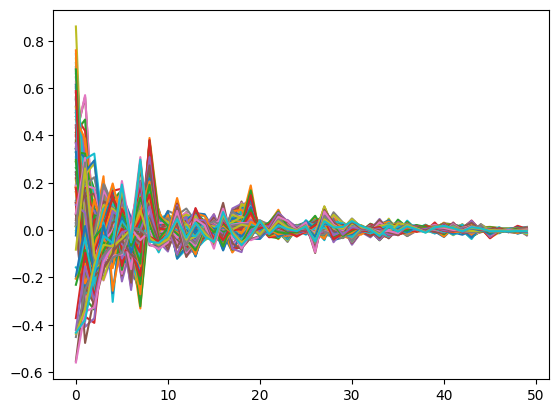

In [23]:
# tt_measurements = np.zeros((4000,2))
# tt_measurements_1stCL = np.zeros((4000,2))
for i in range(100):
        
        with torch.no_grad():
                tfn = GetWFSFrame()
                a = time.perf_counter()
                input_to_network = framePreprocess.ProcessFrame(tfn)
                input_to_network = torch.from_numpy(input_to_network).to(device = device).unsqueeze(0)
                
                
                out = phaseEstimator(input_to_network)
                
                out = out.cpu().numpy().astype(np.float32).T
                # tt_measurements_1stCL[i] = out[:2].squeeze()
                b = time.perf_counter()
       
        print(1/(b - a), end = '\r')  
        plt.plot(out)

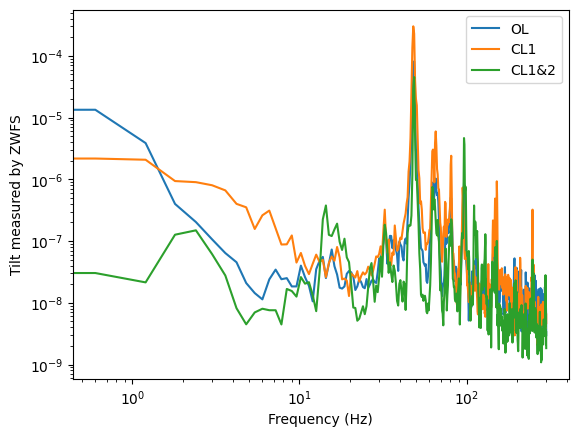

In [61]:
from scipy.signal import welch
tt_measurements_2stCL -= tt_measurements_2stCL.mean(axis = 0)

t, psd_OL = welch(tt_measurements.T, 600, nperseg=1000)
t, psd_CL1 = welch(tt_measurements_1stCL.T, 600, nperseg=1000)
t, psd_CL2 = welch(tt_measurements_2stCL.T, 600, nperseg=1000)
plt.loglog(t, psd_OL[1].T, label = 'OL')
plt.loglog(t, psd_CL1[1].T, label = 'CL1')
plt.loglog(t, psd_CL2[1].T, label = 'CL1&2')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Tilt measured by ZWFS')
plt.legend()

In [64]:
papy_modes_shm = dao.shm('/tmp/papyrus_modes.im.shm')

2026-02-11_11:08:36:960735 [info] dao.c:daoShmShm2Img:707: shm name = papyrus_modes.im.shm
2026-02-11_11:08:36:960766 [info] dao.c:daoShmShm2Img:711: local name: papyrus_modes


In [70]:
tt_measurements_papy_CL = np.zeros((4000,2))
for i in range(4000):
    out = papy_modes_shm.get_data(check = True).astype(np.float32)
    tt_measurements_papy_CL[i] = out[:2].squeeze()
    

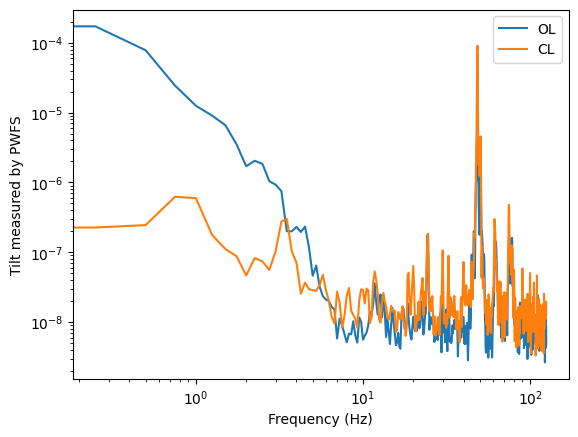

In [74]:
tt_measurements_papy_CL -= tt_measurements_papy_CL.mean(axis = 0)

t, psd_OL_papy = welch(tt_measurements_papy_OL.T, 250, nperseg=1000)
t, psd_CL_papy = welch(tt_measurements_papy_CL.T, 250, nperseg=1000)
# t, psd_CL1 = welch(tt_measurements_1stCL.T, 250, nperseg=1000)
# t, psd_CL2 = welch(tt_measurements_2stCL.T, 600, nperseg=1000)
plt.loglog(t, psd_OL_papy[1].T, label = 'OL')
plt.loglog(t, psd_CL_papy[1].T, label = 'CL')
# plt.loglog(t, psd_CL2[1].T, label = 'CL1&2')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Tilt measured by PWFS')
plt.legend()

In [81]:
M2C = np.load('M2C_KL.npy').astype(np.float32)

In [94]:
dm_command_in = np.expand_dims(M2C[:,3],1) * 0.

In [95]:
dm_commands = np.zeros((97,1), dtype=np.float32)
dmShm.set_data(dm_flat + dm_command_in)

In [61]:
best_flat = np.load('best_flat_IR_PSF.npy').astype(np.float32)
best_flat = np.expand_dims(best_flat[best_flat != 0],1)

In [68]:
dmShm.set_data(best_flat)

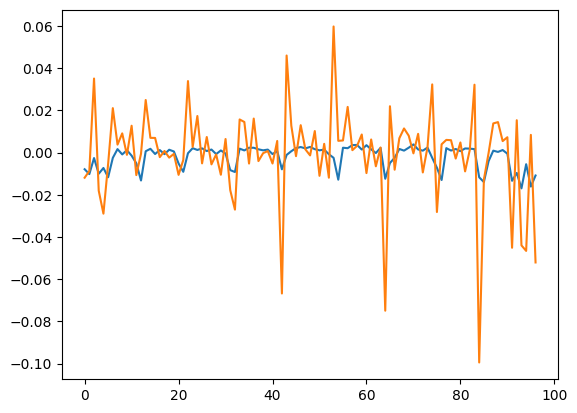

In [59]:
plt.plot(-ncpa*0.2)
plt.plot(best_flat - dm_flat)